# 2026-013 Viral Titers / Restimulation Clone 13

Analysis of restimulation data.

## Initialize Environment

In [1]:
# Load Packages
library(fcexpr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggsci)
library(stringr)
library(jsonlite)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘jsonlite’ was built under R version 4.4.3”


In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig06")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Import sample codebook
codebook <- read.csv("2026-013-D8Panel1Codebook.csv")

# Population schemas file
p.schemas <- "2026-013-D8P1PopulationSchemas.json"

# Design schemas file
d.schemas <- "2026-013-D8P1DesignSchemas.json"

# Output Folder
output_folder <- "2026-013-Restimulation"

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "2026-013-Restimulation.wsp",
                rds_file = "2026-013-Restimulation.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts and MFI
counts <- workspace[["counts"]]
stats  <- workspace[["stats"]]


Attaching package: ‘rlang’


The following objects are masked from ‘package:jsonlite’:

    flatten, unbox



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


The following object is masked from ‘package:jsonlite’:

    flatten




# Process Gating Data
Cleanup data to report only gates below CD8.

In [3]:
# Filter only samples in "Samples" FlowJoGroup
surface <- counts %>% filter((FlowJoGroup %in% c("NoStim", "Restim")))

# codebook contains a mapping of FileName metadata
# Join surface with codebook to get metadata
surface <- surface %>%
    left_join(  codebook,
                by = c("FileName" = "FileName"))

# Rename groups mock/WT/dID to A/B/C
surface <- surface %>%
    mutate(Group = recode(Group, "mock" = "A", "WT" = "B", "dID" = "C"))

# Multiply FractionOfParent by 100 and rename to Percent
surface <- surface %>%
    mutate(FractionOfParent = FractionOfParent * 100) %>%
    rename(Percent = FractionOfParent)

head(surface)


,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,Percent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws,Group,Stim,TotalCount
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,Nostim_dID-1_E01.fcs,root,NA,root,754769,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917
2,Nostim_dID-1_E01.fcs,Lymphocytes,root,Lymphocytes,503407,754769,66.69683,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917
3,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,451723,503407,89.73316,FSC-W,FSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917
4,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,431403,451723,95.50167,SSC-W,SSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917
5,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells/Live,Lymphocytes/Single Cells/Single Cells,Live,346942,431403,80.42179,Comp-PE-CF594-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917
6,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells/Live/CD8,Lymphocytes/Single Cells/Single Cells/Live,CD8,62070,346942,17.89060,Comp-Alexa Fluor 700-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,C,NoStim,25214917


Process df:

In [4]:
# Keep only observations in surface wherin PopulationFullPath contains
# "Lymphocytes/Single Cells/Single Cells/"
surface <- surface %>%
    filter(grepl("Lymphocytes/Single Cells/Single Cells/Live", PopulationFullPath))

# Remove "Lymphocytes/Single Cells/Single Cells/Live/" from PopulationFullPath
surface <- surface %>%
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/", "", PopulationFullPath))

# Keep only PopulationFullPath that contains "Transduced" or is exactly with "CD8"
surface <- surface %>%
    filter(grepl("Transduced", PopulationFullPath) | PopulationFullPath == "CD8")

# Select relevant columns
surface <- surface %>%
    # Rename FileName to ID, remove spaces
    mutate(ID = str_replace_all(FileName, " ", "_")) %>%
    select(ID, colnames(codebook), PopulationFullPath, TotalCount, Count, Percent) %>%
    select(-FileName)

# Remove follwing IDs:
# Restim_dID-2_B02.fcs
# Nostim_dID-2_E02.fcs
# Nostim_mock-5_D05.fcs NO
# Restim_mock-5_A05.fcs NO
surface <- surface %>%
    filter(!(ID %in% c("Restim_dID-2_B02.fcs", "Nostim_dID-2_E02.fcs")))

# Preview
surface %>% head(n = 20)

,ID,Group,Stim,TotalCount,PopulationFullPath,Count,Percent
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8,62070,17.89059843
2,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced,11277,18.16819720
3,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced/DN,7157,63.46546067
4,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced/DP,67,0.59412964
5,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced/Early,9459,83.87869114
6,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced/IFNg,8,0.07094085
7,Nostim_dID-1_E01.fcs,C,NoStim,25214917,CD8/Transduced/Late,1129,10.01152789
8,Nostim_dID-1_E01.fcs,C,NoStim,25214917,"CD8/Transduced/Q1: TOX- , CD8a+",291,2.58047353
9,Nostim_dID-1_E01.fcs,C,NoStim,25214917,"CD8/Transduced/Q2: TOX+ , CD8a+",9429,83.61266294


Combine IFNg and TNFa percents:

In [5]:
# Remove Count and spread surface, Percent by PopulationFullPath
surface <- surface %>% select(-Count) %>%
    pivot_wider(names_from = PopulationFullPath, values_from = Percent)

# Add CD8/Transduced/IFNg and CD8/Transduced/DP into CD8/Transduced/IFNg_all
# Add CD8/Transduced/TNFa and CD8/Transduced/DP into CD8/Transduced/TNFa_all
surface <- surface %>%
    mutate(`CD8/Transduced/IFNg_all` = `CD8/Transduced/IFNg` + `CD8/Transduced/DP`) %>%
    mutate(`CD8/Transduced/TNFa_all` = `CD8/Transduced/TNFa` + `CD8/Transduced/DP`)


# Gather columns from 4 - beyond, into key = PopulationFullPath, value = Percent
surface <- surface %>%
    pivot_longer(cols = 5:ncol(surface), names_to = "PopulationFullPath", values_to = "Percent")

Calculate total percent:

In [6]:
# Without rounding at all
# Keep PopulationString (a copy of PopulationFullPath) since finalize_flow_table
# drops PopulationFullPath, but we need it later to join in MFI values
total_percent <- compute_percent_of_total(surface) %>%
    mutate(PopulationString = PopulationFullPath) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL) %>%
    mutate(RealCount = PercentOfTotal * TotalCount / 100)

head(total_percent, n = 10)


ID,Group,Population,Population1Deriv,Population2Deriv,Stim,TotalCount,PopulationString,Percent,PercentOfTotal,RealCount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Nostim_WT-1_D07.fcs,B,CD8,NA,NA,NoStim,33271243,CD8,13.3870619,13.387061939,4454041.844
Nostim_WT-1_D07.fcs,B,CD8,Transduced,NA,NoStim,33271243,CD8/Transduced,13.2645552,1.775734221,590808.839
Nostim_WT-1_D07.fcs,B,CD8,Transduced,DN,NoStim,33271243,CD8/Transduced/DN,66.3181479,1.177634047,391813.480
Nostim_WT-1_D07.fcs,B,CD8,Transduced,DP,NoStim,33271243,CD8/Transduced/DP,0.5334471,0.009472603,3151.653
Nostim_WT-1_D07.fcs,B,CD8,Transduced,Early,NoStim,33271243,CD8/Transduced/Early,37.8427398,0.671986481,223578.252
Nostim_WT-1_D07.fcs,B,CD8,Transduced,IFNg,NoStim,33271243,CD8/Transduced/IFNg,0.2560546,0.004546850,1512.793
Nostim_WT-1_D07.fcs,B,CD8,Transduced,IFNg_all,NoStim,33271243,CD8/Transduced/IFNg_all,0.7895018,0.014019453,4664.446
Nostim_WT-1_D07.fcs,B,CD8,Transduced,Late,NoStim,33271243,CD8/Transduced/Late,45.8551158,0.814264983,270916.077
Nostim_WT-1_D07.fcs,B,CD8,Transduced,"Q10: CX3CR1+ , TOX+",NoStim,33271243,"CD8/Transduced/Q10: CX3CR1+ , TOX+",0.7468260,0.013261645,4412.314


Extract MFI (Geometric Mean) per population and channel:

In [7]:
mfi <- stats %>%
    # Keep only relevant columns in stats
    select(FileName, PopulationFullPath, channel, value) %>%
    # Relevel PopulationFullPath the same way surface's PopulationFullPath was relevelled
    mutate(
        FileName = str_replace_all(FileName, " ", "_"),
        PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/", "", PopulationFullPath)) %>%
    # Rename channels
    mutate(channel = case_when(
        channel == "Comp-APC-A" ~ "mfi.TOX",
        channel == "Comp-APC-Cy7-A" ~ "mfi.PD1",
        channel == "Comp-FITC-A" ~ "mfi.TCF1",
        channel == "Comp-PE W_561-A" ~ "mfi.TNFa",
        channel == "Comp-PE-Cy7-A" ~ "mfi.IFNg")
    ) %>%
    # Pivot wider to have one row per FileName and PopulationFullPath, with columns for each channel
    pivot_wider(names_from = channel, values_from = value)

head(mfi)

FileName,PopulationFullPath,mfi.TOX,mfi.PD1,mfi.TCF1,mfi.TNFa,mfi.IFNg
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Nostim_dID-1_E01.fcs,CD8/Endogenous/Naive/DN,407.5689,31.26371,2449.3174,338.6157,485.0382
Nostim_dID-1_E01.fcs,CD8/Endogenous/Naive/DP,NaN,NaN,NaN,NaN,NaN
Nostim_dID-1_E01.fcs,CD8/Endogenous/Naive/IFNg,NaN,NaN,NaN,NaN,NaN
Nostim_dID-1_E01.fcs,CD8/Endogenous/Naive/TNFa,343.2296,196.38570,2845.9387,2973.6133,962.6909
Nostim_dID-1_E01.fcs,CD8/Transduced,3569.8833,589.02246,385.0749,1450.3329,922.4874
Nostim_dID-1_E01.fcs,CD8/Transduced/DN,3028.5242,508.09900,321.6835,1088.1613,833.4478


In [8]:
# Combine mfi (FileName, PopulationFullPath) with total_percent (ID, PopulationString)
all.data <- total_percent %>%
    left_join(mfi, by = c("ID" = "FileName", "PopulationString" = "PopulationFullPath")) %>%
    select(
        ID, Group, Stim, Population, Population1Deriv, Population2Deriv,
        TotalCount, Percent, PercentOfTotal, RealCount,
        mfi.TOX, mfi.PD1, mfi.TCF1, mfi.TNFa, mfi.IFNg
    )

head(all.data, n = 20)

# Save all.data to CSV
if (!dir.exists(output_folder)) {
    dir.create(output_folder)
}
write.csv(all.data, file = paste0(output_folder, "/measured_data.csv"), row.names = FALSE, quote = FALSE)

ID,Group,Stim,Population,Population1Deriv,Population2Deriv,TotalCount,Percent,PercentOfTotal,RealCount,mfi.TOX,mfi.PD1,mfi.TCF1,mfi.TNFa,mfi.IFNg
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Nostim_WT-1_D07.fcs,B,NoStim,CD8,NA,NA,33271243,13.38706194,1.338706e+01,4454041.8442,NA,NA,NA,NA,NA
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,NA,33271243,13.26455521,1.775734e+00,590808.8393,632.5898,473.7252,332.3590,1456.3458,798.9212
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,DN,33271243,66.31814787,1.177634e+00,391813.4797,545.9533,421.1370,290.8954,1158.8430,704.6844
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,DP,33271243,0.53344714,9.472603e-03,3151.6528,1192.4038,863.6964,1065.2001,3360.1431,4307.5005
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,Early,33271243,37.84273978,6.719865e-01,223578.2517,647.7254,466.4932,318.4705,1366.6057,754.4901
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,IFNg,33271243,0.25605462,4.546850e-03,1512.7934,727.4213,306.0735,843.9786,908.5627,3622.1980
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,IFNg_all,33271243,0.78950176,1.401945e-02,4664.4462,NA,NA,NA,NA,NA
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,Late,33271243,45.85511576,8.142650e-01,270916.0772,629.1580,490.6702,344.6263,1592.6914,862.9600
Nostim_WT-1_D07.fcs,B,NoStim,CD8,Transduced,"Q10: CX3CR1+ , TOX+",33271243,0.74682599,1.326164e-02,4412.3140,3785.6626,717.6901,587.2739,1825.2097,1177.9449


## Process Population and Design Schemas

In [9]:
# Load PopulationSchemas.json to check if grouped populations are defined as groups in the schema
p.schemas <- fromJSON(p.schemas)
p.schemas <- lapply(p.schemas, as.character)

# Add IFNg_all and TNFa_all to p.schemas
p.schemas[["StimCombined"]] <- c("IFNg_all", "TNFa_all")

p.schemas.names <- names(p.schemas)

# Inspect structure
p.schemas

$Stim
[1] "IFNg" "DP"   "DN"   "TNFa"

$Pipkin
[1] "Early" "Late"  "Term"  "Undef"

$StimCombined
[1] "IFNg_all" "TNFa_all"

In [10]:
# Load DesignSchemas.json
d.schemas <- fromJSON(d.schemas)
d.schemas <- lapply(d.schemas, as.character)

# Inspect structure
d.schemas

$Group
[1] "A" "B" "C"

$Stim
[1] "NoStim" "ReStim"

## Plot

In [11]:
# Use theme_bw, base 12, not bold, and remove legend
theme <- theme_bw(
    base_size = 14,
    base_family = "sans"
) +
    theme(
        axis.text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        axis.text.x = element_text(angle = 45, hjust = 0.5, vjust = 0.5, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),
        axis.title.x = element_blank(),

        # Remove facet strip background + box
        strip.background = element_rect(fill = NA, color = NA),
        strip.text = element_text(color = "black"),  # optional: keep text styling clean

        legend.position = "none",
        plot.title = element_text(size = 12),
        panel.grid = element_blank()
    )

In [12]:
# Group colors and comparisons, reused for all plots below
abc_colors <- c("A" = "#808180", "B" = "#00A087", "C" = "#F39B7F")
abc_comparisons <- list(c("A", "B"), c("A", "C"), c("B", "C"))

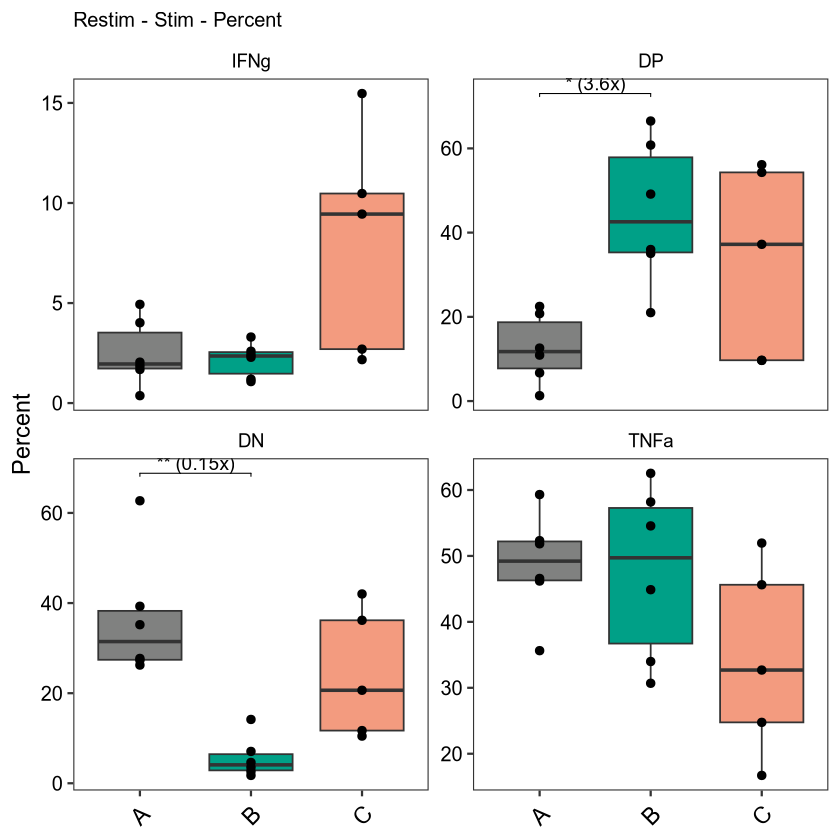

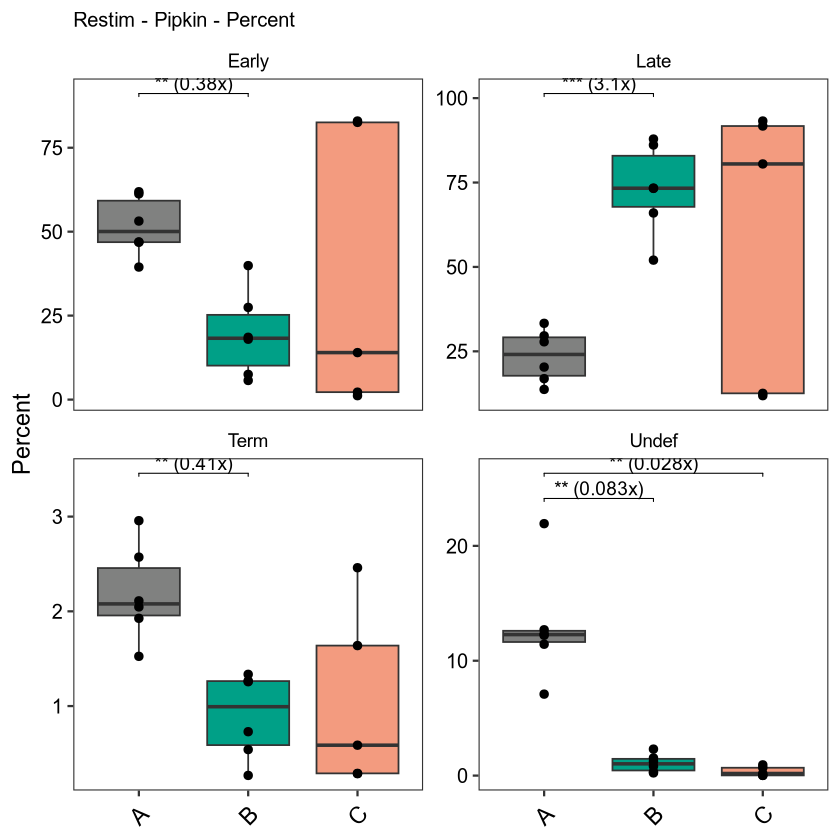

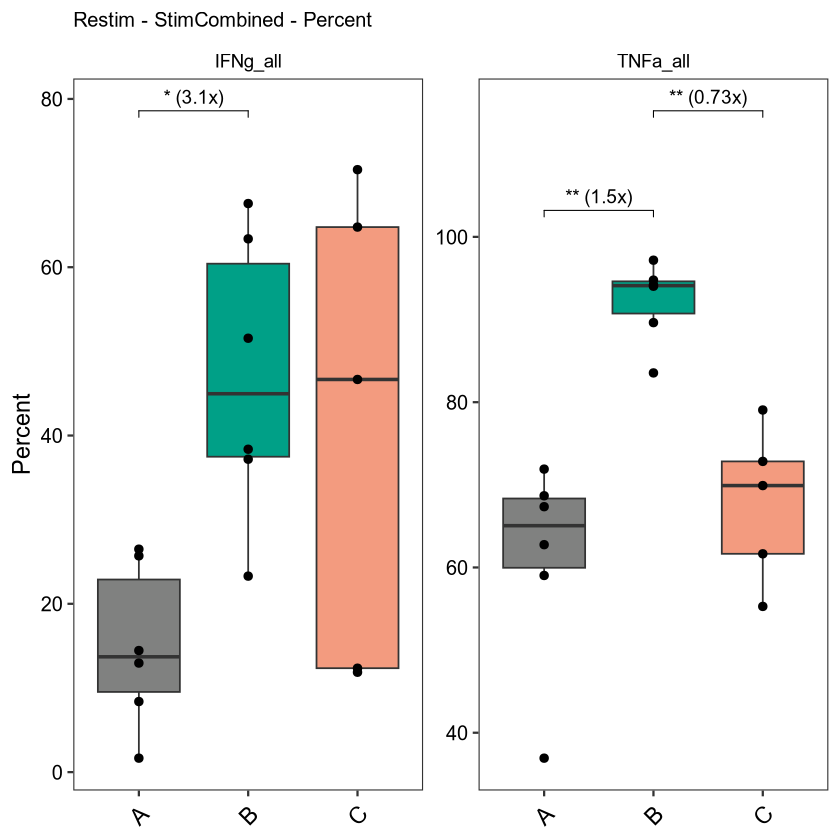

In [13]:
# Loop on all schemas on the Population2Deriv level
# Plot Percents
for(schema in p.schemas.names) {

    # Select only Population2Deriv within the current schema
    # Factor Population2Deriv to have levels in order of appearance
    plot.data.df <- total_percent %>%
        filter(
            Stim == "ReStim",
            Population2Deriv %in% p.schemas[[schema]]
            ) %>%
        mutate(
            Population2Deriv = factor(
                Population2Deriv, 
                levels = 
                    p.schemas[[schema]],
                    ),
            Group = factor(Group, levels = d.schemas[["Group"]]),
        )
        

    # Calculate p-values and adjusted p-values for comparisons using plot_padj function
    plot.stat.df <- plot_padj(
        data = plot.data.df,
        comparisons = abc_comparisons,
        y_col = "Percent",
        x_col = "Group",
        facet_col = "Population2Deriv",
        step_fraction = 0.1,
        min_step = 0.5
    )
    # Save plot.stat.df to a CSV file for inspection
    write.csv(plot.stat.df, paste0(output_folder, "/stats-Restim-", schema, "-Percent.csv"), row.names = FALSE)

    # Round plot.stat.df column foldmean to one significant digit
    # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
    plot.stat.df <- plot.stat.df %>%
        mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
        mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

    p <- ggplot(plot.data.df, aes(x = Group, y = Percent, fill = Group)) +
        geom_boxplot(outlier.shape = NA) +
        geom_point(size = 2) +
        facet_wrap(~Population2Deriv, ncol = 2, scales = "free_y") +
        scale_fill_manual(values = abc_colors) +
        theme +
        stat_pvalue_manual(
            plot.stat.df %>% filter(p.adj < 0.05),
            label = "p.adj.fold",   # adjusted p-value stars
            tip.length = 0.01,
            size = 4,
            inherit.aes = FALSE       # important fix
        ) + ggtitle(paste0("Restim - ", schema, " - Percent"))

    print(p)

    ggsave(
        filename = paste0(output_folder, "/plots-Restim-", schema, "-Percent.pdf"),
        plot = p,
        width = 10,
        height = 8,
        units = "in"
    )

}


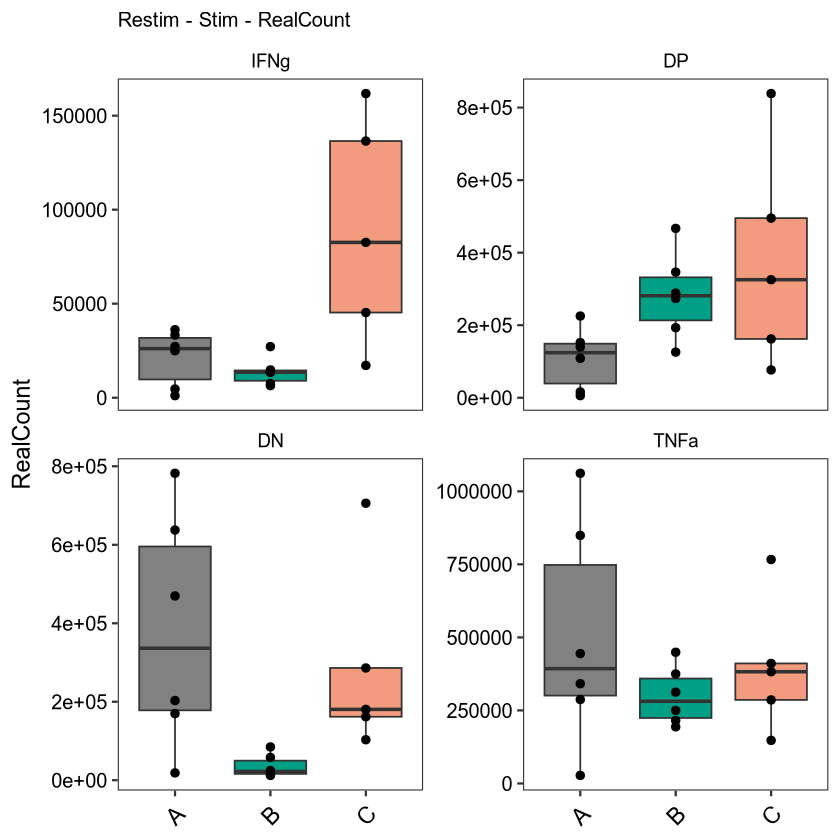

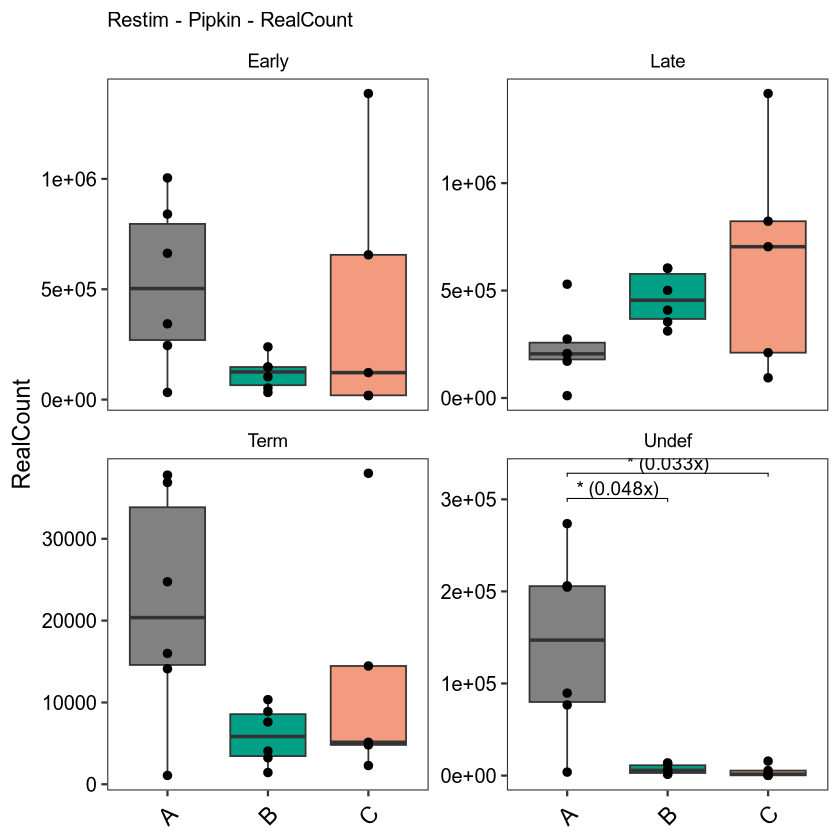

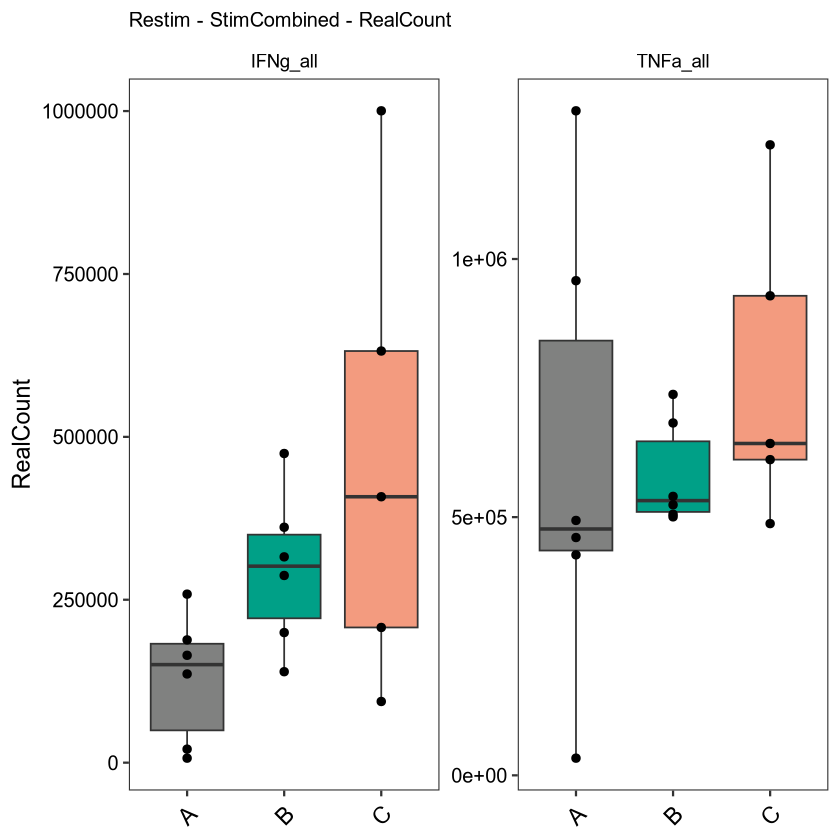

In [14]:
# Loop on all schemas on the Population2Deriv level
# Plot RealCounts
for(schema in p.schemas.names) {

    # Select only Population2Deriv within the current schema
    # Factor Population2Deriv to have levels in order of appearance
    plot.data.df <- total_percent %>%
        filter(
            Stim == "ReStim",
            Population2Deriv %in% p.schemas[[schema]]
            ) %>%
        mutate(
            Population2Deriv = factor(
                Population2Deriv, 
                levels = 
                    p.schemas[[schema]],
                    ),
            Group = factor(Group, levels = d.schemas[["Group"]]),
        )
        

    # Calculate p-values and adjusted p-values for comparisons using plot_padj function
    plot.stat.df <- plot_padj(
        data = plot.data.df,
        comparisons = abc_comparisons,
        y_col = "RealCount",
        x_col = "Group",
        facet_col = "Population2Deriv",
        step_fraction = 0.1,
        min_step = 0.5
    )
    # Save plot.stat.df to a CSV file for inspection
    write.csv(plot.stat.df, paste0(output_folder, "/stats-Restim-", schema, "-RealCount.csv"), row.names = FALSE)

    # Round plot.stat.df column foldmean to one significant digit
    # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
    plot.stat.df <- plot.stat.df %>%
        mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
        mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

    p <- ggplot(plot.data.df, aes(x = Group, y = RealCount, fill = Group)) +
        geom_boxplot(outlier.shape = NA) +
        geom_point(size = 2) +
        facet_wrap(~Population2Deriv, ncol = 2, scales = "free_y") +
        scale_fill_manual(values = abc_colors) +
        theme +
        stat_pvalue_manual(
            plot.stat.df %>% filter(p.adj < 0.05),
            label = "p.adj.fold",   # adjusted p-value stars
            tip.length = 0.01,
            size = 4,
            inherit.aes = FALSE       # important fix
        ) + ggtitle(paste0("Restim - ", schema, " - RealCount"))

    print(p)

    ggsave(
        filename = paste0(output_folder, "/plots-Restim-", schema, "-RealCount.pdf"),
        plot = p,
        width = 10,
        height = 8,
        units = "in"
    )

}

## Figures

Restim: IFNg/TNFa populations (DN, IFNg, DP, TNFa) plus combined IFNg_all/TNFa_all, by Group.

Restim - Stim - Percent, as a standalone plot (outside the generic loop above) so its PDF size can be tuned independently.

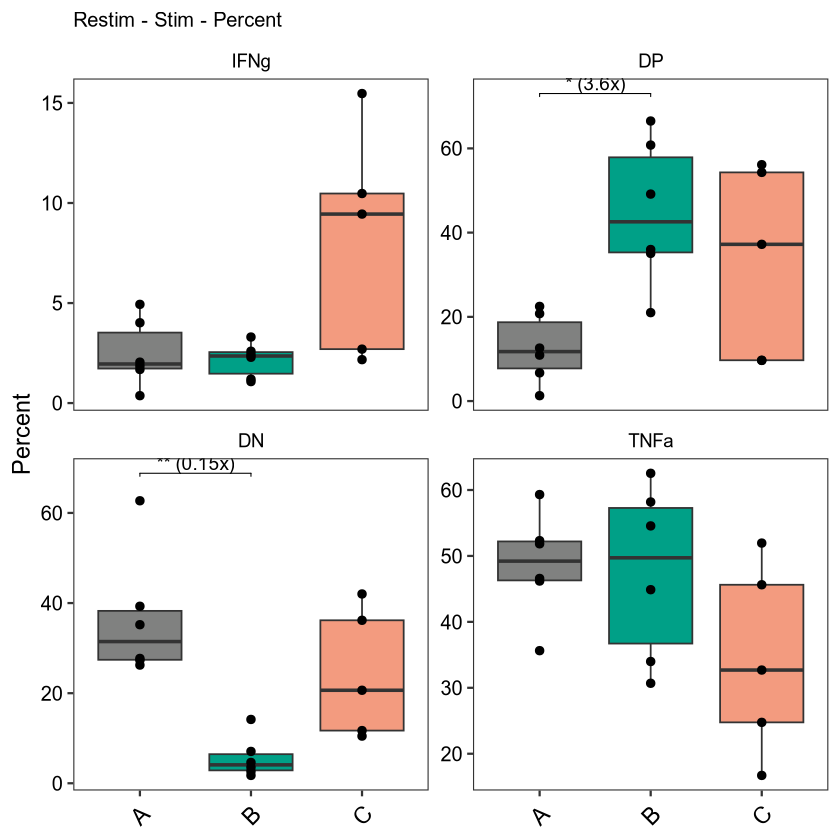

In [15]:
# Restim - Stim - Percent (IFNg, DP, DN, TNFa), standalone so width/height
# below can be adjusted freely without affecting the generic per-schema loop
stim_percent.df <- total_percent %>%
    filter(
        Stim == "ReStim",
        Population2Deriv %in% p.schemas[["Stim"]]
    ) %>%
    mutate(
        Population2Deriv = factor(Population2Deriv, levels = p.schemas[["Stim"]]),
        Group = factor(Group, levels = d.schemas[["Group"]])
    )

plot.stat.df <- plot_padj(
    data = stim_percent.df,
    comparisons = abc_comparisons,
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population2Deriv",
    step_fraction = 0.1,
    min_step = 0.5
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Restim-Stim-Percent.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(stim_percent.df, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population2Deriv, ncol = 2, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) + ggtitle("Restim - Stim - Percent")

print(p)

# PDF size for this specific plot -- edit freely, independent of the loop above
pdf_width  <- 3
pdf_height <- 3

ggsave(
    filename = paste0(output_folder, "/figs-Restim-Stim-Percent.pdf"),
    plot = p,
    width = pdf_width,
    height = pdf_height,
    units = "in"
)

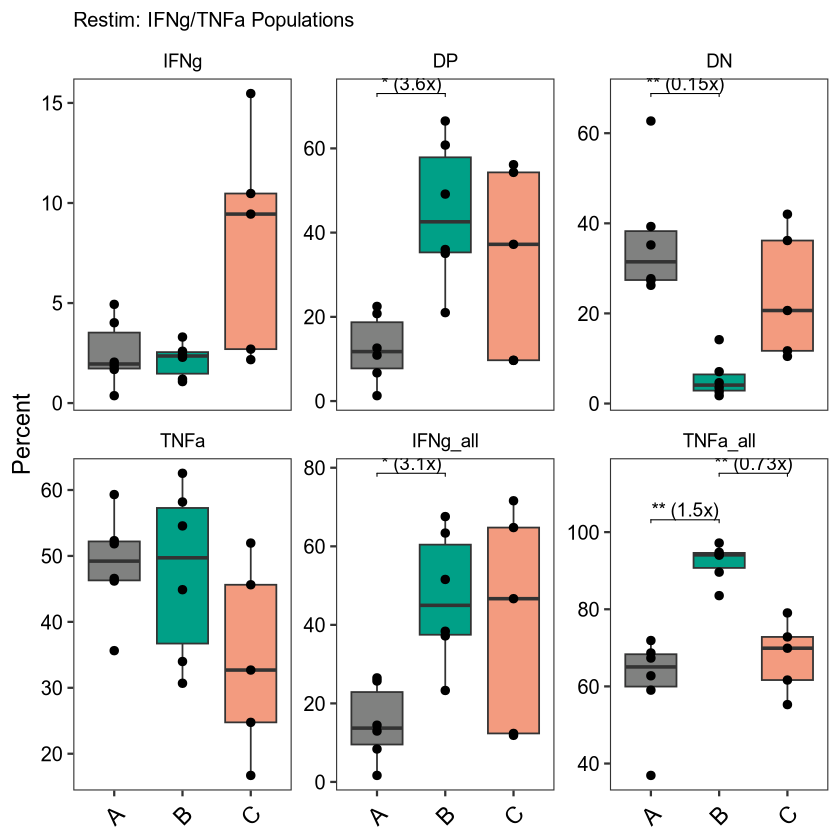

In [16]:
# Restim only: DN/IFNg/DP/TNFa plus combined IFNg_all/TNFa_all, in one figure
stim_levels <- c(p.schemas[["Stim"]], p.schemas[["StimCombined"]])

stim_combined.df <- total_percent %>%
    filter(
        Stim == "ReStim",
        Population2Deriv %in% stim_levels
    ) %>%
    mutate(
        Population2Deriv = factor(Population2Deriv, levels = stim_levels),
        Group = factor(Group, levels = d.schemas[["Group"]])
    )

plot.stat.df <- plot_padj(
    data = stim_combined.df,
    comparisons = abc_comparisons,
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population2Deriv",
    step_fraction = 0.1,
    min_step = 0.5
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Restim-StimCombined-Percent.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(stim_combined.df, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population2Deriv, ncol = 3, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) + ggtitle("Restim: IFNg/TNFa Populations")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Restim-StimCombined-Percent.pdf"),
    plot = p,
    width = 10,
    height = 7,
    units = "in"
)

Control: TOX MFI by Group in all Transduced cells, faceted by Stim (confirms transduction/staining worked and restimulation boosts TOX).

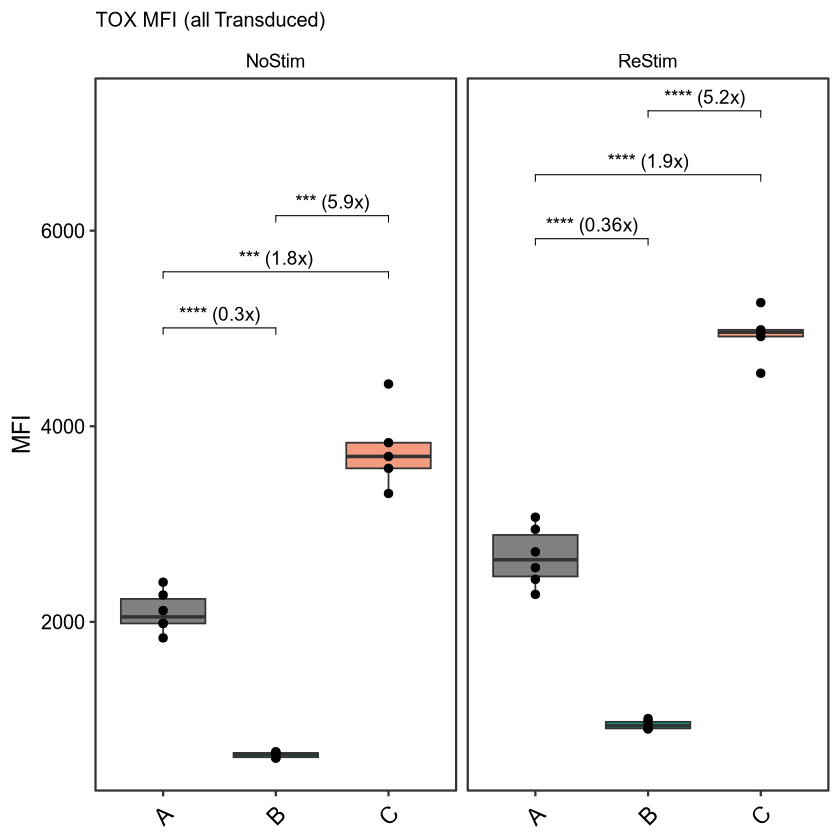

In [17]:
# TOX MFI by Group, all Transduced cells (Population2Deriv NA), faceted by Stim
tox.df <- all.data %>%
    filter(
        Population1Deriv == "Transduced",
        is.na(Population2Deriv)
    ) %>%
    mutate(
        Group = factor(Group, levels = d.schemas[["Group"]]),
        Stim = factor(Stim, levels = d.schemas[["Stim"]])
    )

plot.stat.df <- plot_padj(
    data = tox.df,
    comparisons = abc_comparisons,
    y_col = "mfi.TOX",
    x_col = "Group",
    facet_col = "Stim",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-TOXmfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(tox.df, aes(x = Group, y = mfi.TOX, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Stim) +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("TOX MFI (all Transduced)")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-TOXmfi.pdf"),
    plot = p,
    width = 4.5,
    height = 3,
    units = "in"
)

PD1 MFI by Group in all Transduced cells, faceted by Stim.

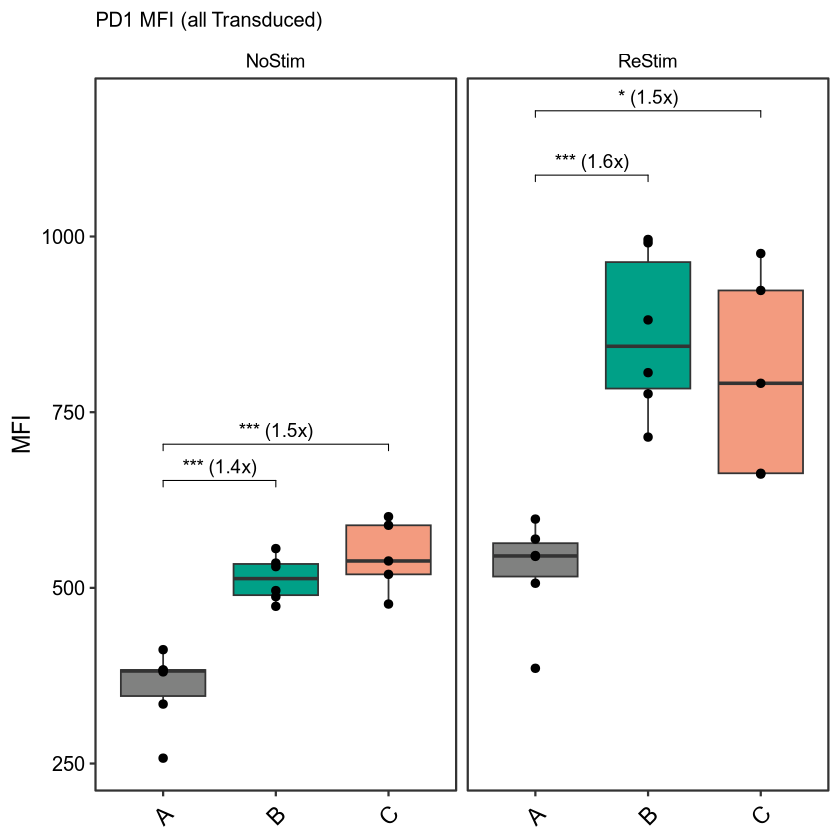

In [18]:
# PD1 MFI by Group, all Transduced cells (Population2Deriv NA), faceted by Stim
pd1.df <- all.data %>%
    filter(
        Population1Deriv == "Transduced",
        is.na(Population2Deriv)
    ) %>%
    mutate(
        Group = factor(Group, levels = d.schemas[["Group"]]),
        Stim = factor(Stim, levels = d.schemas[["Stim"]])
    )

plot.stat.df <- plot_padj(
    data = pd1.df,
    comparisons = abc_comparisons,
    y_col = "mfi.PD1",
    x_col = "Group",
    facet_col = "Stim",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-PD1mfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(pd1.df, aes(x = Group, y = mfi.PD1, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Stim) +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("PD1 MFI (all Transduced)")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-PD1mfi.pdf"),
    plot = p,
    width = 4.5,
    height = 3,
    units = "in"
)

IFNg + TNFa MFI by Group in all Transduced cells: rows = Marker (IFNg, TNFa), columns = Stim.

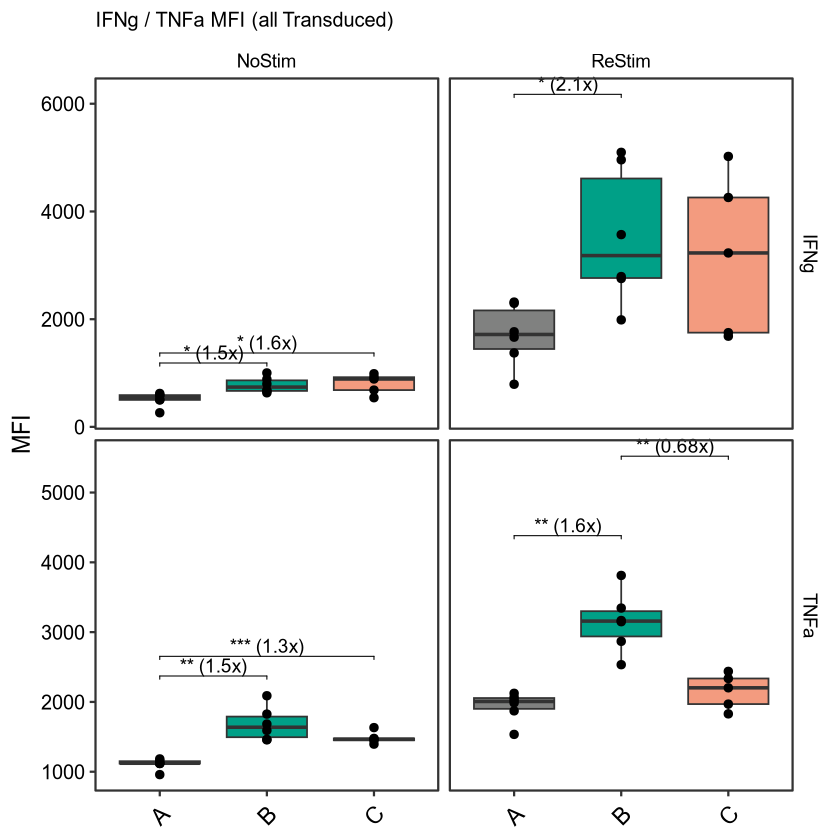

In [19]:
# IFNg + TNFa MFI by Group, all Transduced cells (Population2Deriv NA)
# facet_grid: rows = Marker (IFNg, TNFa), columns = Stim
cytokine_mfi.df <- all.data %>%
    filter(
        Population1Deriv == "Transduced",
        is.na(Population2Deriv)
    ) %>%
    select(ID, Group, Stim, mfi.IFNg, mfi.TNFa) %>%
    pivot_longer(cols = c(mfi.IFNg, mfi.TNFa), names_to = "Marker", values_to = "MFI") %>%
    mutate(
        Marker = recode(Marker, "mfi.IFNg" = "IFNg", "mfi.TNFa" = "TNFa"),
        Marker = factor(Marker, levels = c("IFNg", "TNFa")),
        Group = factor(Group, levels = d.schemas[["Group"]]),
        Stim = factor(Stim, levels = d.schemas[["Stim"]]),
        # Combined key so plot_padj tests/positions each Marker x Stim panel independently
        FacetKey = paste(Marker, Stim, sep = "|")
    )

plot.stat.df <- plot_padj(
    data = cytokine_mfi.df,
    comparisons = abc_comparisons,
    y_col = "MFI",
    x_col = "Group",
    facet_col = "FacetKey",
    paired = FALSE,
    step_fraction = 0.25,
    min_step = 50
) %>%
    separate(FacetKey, into = c("Marker", "Stim"), sep = "\\|", remove = FALSE) %>%
    mutate(
        Marker = factor(Marker, levels = c("IFNg", "TNFa")),
        Stim = factor(Stim, levels = d.schemas[["Stim"]])
    )

write.csv(plot.stat.df, paste0(output_folder, "/stats-IFNgTNFamfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(cytokine_mfi.df, aes(x = Group, y = MFI, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_grid(Marker ~ Stim, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("IFNg / TNFa MFI (all Transduced)")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-IFNgTNFamfi.pdf"),
    plot = p,
    width = 5,
    height = 6.5,
    units = "in"
)

TOX + IFNg + TNFa MFI by Group in all Transduced cells: rows = Marker (TOX, IFNg, TNFa), columns = Stim.

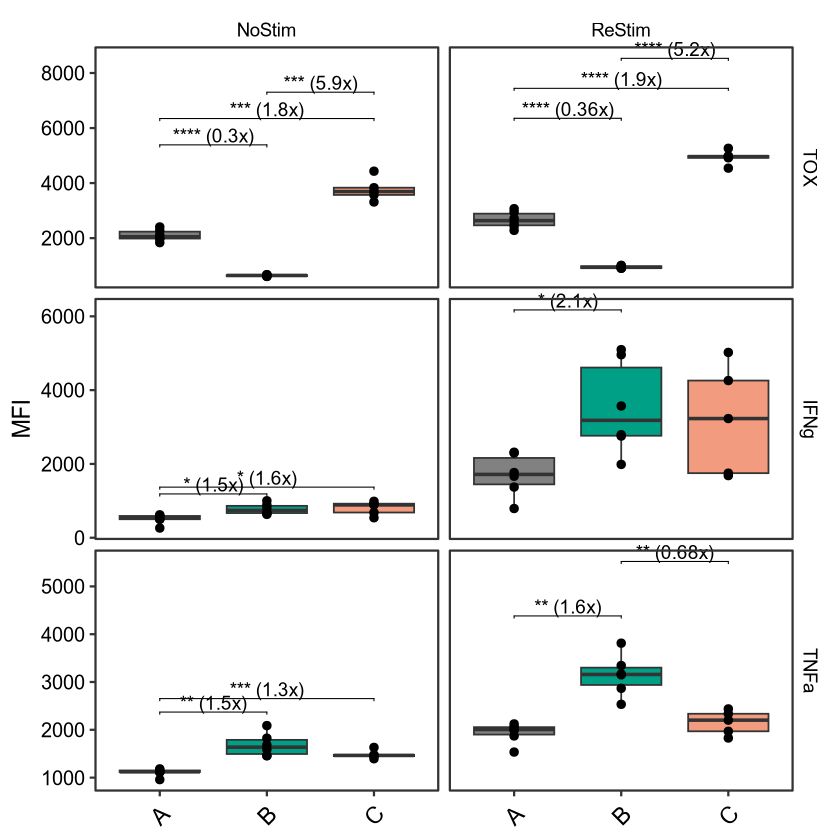

In [20]:
# TOX + IFNg + TNFa MFI by Group, all Transduced cells (Population2Deriv NA)
# facet_grid: rows = Marker (TOX, IFNg, TNFa), columns = Stim
marker_mfi.df <- all.data %>%
    filter(
        Population1Deriv == "Transduced",
        is.na(Population2Deriv)
    ) %>%
    select(ID, Group, Stim, mfi.TOX, mfi.IFNg, mfi.TNFa) %>%
    pivot_longer(cols = c(mfi.TOX, mfi.IFNg, mfi.TNFa), names_to = "Marker", values_to = "MFI") %>%
    mutate(
        Marker = recode(Marker, "mfi.TOX" = "TOX", "mfi.IFNg" = "IFNg", "mfi.TNFa" = "TNFa"),
        Marker = factor(Marker, levels = c("TOX", "IFNg", "TNFa")),
        Group = factor(Group, levels = d.schemas[["Group"]]),
        Stim = factor(Stim, levels = d.schemas[["Stim"]]),
        # Combined key so plot_padj tests/positions each Marker x Stim panel independently
        FacetKey = paste(Marker, Stim, sep = "|")
    )

plot.stat.df <- plot_padj(
    data = marker_mfi.df,
    comparisons = abc_comparisons,
    y_col = "MFI",
    x_col = "Group",
    facet_col = "FacetKey",
    paired = FALSE,
    step_fraction = 0.25,
    min_step = 50
) %>%
    separate(FacetKey, into = c("Marker", "Stim"), sep = "\\|", remove = FALSE) %>%
    mutate(
        Marker = factor(Marker, levels = c("TOX", "IFNg", "TNFa")),
        Stim = factor(Stim, levels = d.schemas[["Stim"]])
    )

write.csv(plot.stat.df, paste0(output_folder, "/stats-TOXIFNgTNFamfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(marker_mfi.df, aes(x = Group, y = MFI, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_grid(Marker ~ Stim, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-TOXIFNgTNFamfi.pdf"),
    plot = p,
    width = 4,
    height = 6,
    units = "in"
)

# 2026-013 Viral Titering

In [21]:
# Load titer data
titer <- read.csv("Titers.csv")
head(titer)

,Sample,Transduction,Group,Fraction,A.frac,B.frac,Dilution,Counts
,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
1,1,mock,A,A,0.3728115,0.2976313,5,25;23;25
2,2,mock,A,A,0.2779783,0.3164862,5,4;14;14;4;17;15
3,3,mock,A,A,0.3676768,0.2616162,5,18;13;14;14;25;14
4,4,mock,A,B,0.3257143,0.3211429,5,11;11;16;19;10;16
5,5,mock,A,B,0.3287129,0.2950495,5,15;15;17;17;17;22
6,6,mock,A,,0.3780488,0.2934451,NA,


In [22]:
# Keep only if counts is present
titer <- titer %>%
    filter(Counts != "")

head(titer)

,Sample,Transduction,Group,Fraction,A.frac,B.frac,Dilution,Counts
,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
1,1,mock,A,A,0.3728115,0.2976313,5,25;23;25
2,2,mock,A,A,0.2779783,0.3164862,5,4;14;14;4;17;15
3,3,mock,A,A,0.3676768,0.2616162,5,18;13;14;14;25;14
4,4,mock,A,B,0.3257143,0.3211429,5,11;11;16;19;10;16
5,5,mock,A,B,0.3287129,0.2950495,5,15;15;17;17;17;22
6,7,RUNX3-WT,B,A,0.3967789,0.2313324,4,25;27;11


In [23]:
# Counts have replicate measurements by selected dilution.
# Split Counts by ; and compute mean and sd of counts for each Sample
titer <- titer %>%
    mutate(
        MeanCount = sapply(strsplit(as.character(Counts), ";"), function(x) mean(as.numeric(x), na.rm = TRUE)),
        SDCount = sapply(strsplit(as.character(Counts), ";"), function(x) sd(as.numeric(x), na.rm = TRUE))
    )
head(titer)

,Sample,Transduction,Group,Fraction,A.frac,B.frac,Dilution,Counts,MeanCount,SDCount
,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>
1,1,mock,A,A,0.3728115,0.2976313,5,25;23;25,24.33333,1.154701
2,2,mock,A,A,0.2779783,0.3164862,5,4;14;14;4;17;15,11.33333,5.785038
3,3,mock,A,A,0.3676768,0.2616162,5,18;13;14;14;25;14,16.33333,4.589844
4,4,mock,A,B,0.3257143,0.3211429,5,11;11;16;19;10;16,13.83333,3.656045
5,5,mock,A,B,0.3287129,0.2950495,5,15;15;17;17;17;22,17.16667,2.562551
6,7,RUNX3-WT,B,A,0.3967789,0.2313324,4,25;27;11,21.00000,8.717798


In [24]:
# Compute TiterPerML = MeanCount * (10 ^ Dilution) * 5
# Multiplied by 5 as 1/5 was used for the dilution series
titer <- titer %>%
    mutate(TiterPerML = MeanCount * (10 ^ Dilution) * 5)

# Recover per Spleen from TiterPerML by dividing by frac (A.frac, B.frac)
# depending on Fraction used (A or B)
titer <- titer %>%
    mutate(
        TiterPerSpleen = case_when(
            Fraction == "A" ~ TiterPerML / A.frac,
            Fraction == "B" ~ TiterPerML / B.frac,
            TRUE ~ NA_real_
        ),
        Group = factor(Group, levels = d.schemas[["Group"]])
    )

head(titer)


,Sample,Transduction,Group,Fraction,A.frac,B.frac,Dilution,Counts,MeanCount,SDCount,TiterPerML,TiterPerSpleen
,<int>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,mock,A,A,0.3728115,0.2976313,5,25;23;25,24.33333,1.154701,12166667,32634899
2,2,mock,A,A,0.2779783,0.3164862,5,4;14;14;4;17;15,11.33333,5.785038,5666667,20385281
3,3,mock,A,A,0.3676768,0.2616162,5,18;13;14;14;25;14,16.33333,4.589844,8166667,22211538
4,4,mock,A,B,0.3257143,0.3211429,5,11;11;16;19;10;16,13.83333,3.656045,6916667,21537663
5,5,mock,A,B,0.3287129,0.2950495,5,15;15;17;17;17;22,17.16667,2.562551,8583333,29091163
6,7,RUNX3-WT,B,A,0.3967789,0.2313324,4,25;27;11,21.00000,8.717798,1050000,2646310


In [25]:
# Save processed titer data to CSV
write.csv(titer, file = paste0(output_folder, "/processed_titers.csv"), row.names = FALSE, quote = FALSE)

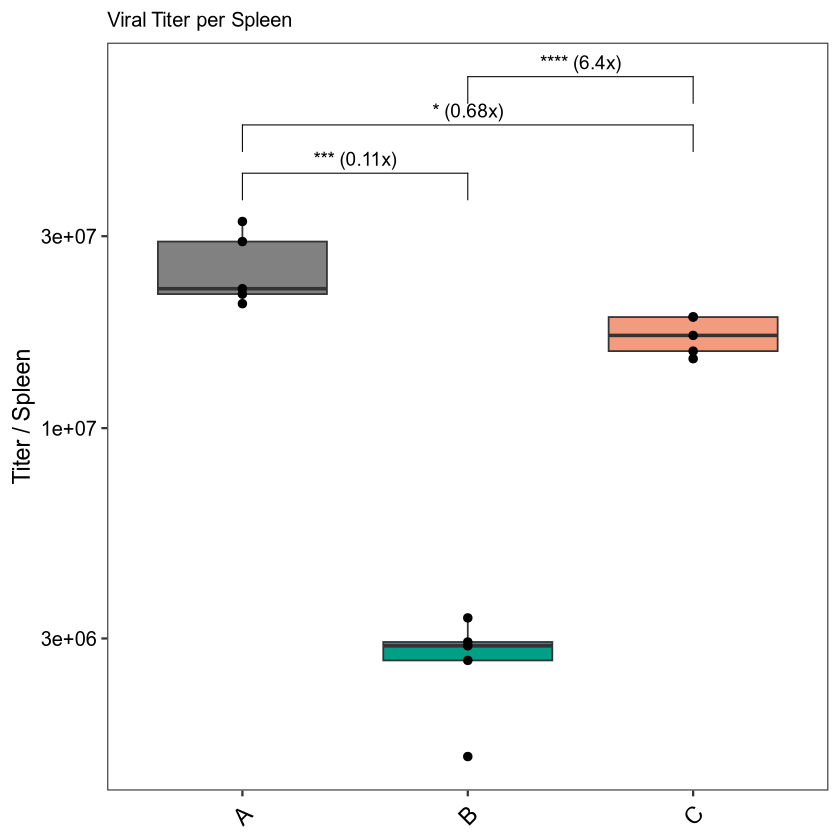

In [36]:
titer.plot.stat.df <- plot_padj(
    data = titer,
    comparisons = abc_comparisons,
    y_col = "TiterPerSpleen",
    x_col = "Group",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 1e6
)

write.csv(titer.plot.stat.df, paste0(output_folder, "/stats-TiterPerSpleen.csv"), row.names = FALSE)

titer.plot.stat.df <- titer.plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

titer <- titer %>% filter(TiterPerSpleen > 0)

ymax <- max(titer$TiterPerSpleen, na.rm = TRUE)

titer.plot.stat.df$y.position <- log10(ymax) + 0.12 * seq_len(nrow(titer.plot.stat.df))

p <- ggplot(titer, aes(x = Group, y = TiterPerSpleen, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    scale_fill_manual(values = abc_colors) +
    scale_y_log10() +
    theme +
    stat_pvalue_manual(
        titer.plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Titer / Spleen") + ggtitle("Viral Titer per Spleen")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-TiterPerSpleen.pdf"),
    plot = p,
    width = 2.5,
    height = 3,
    units = "in"
)

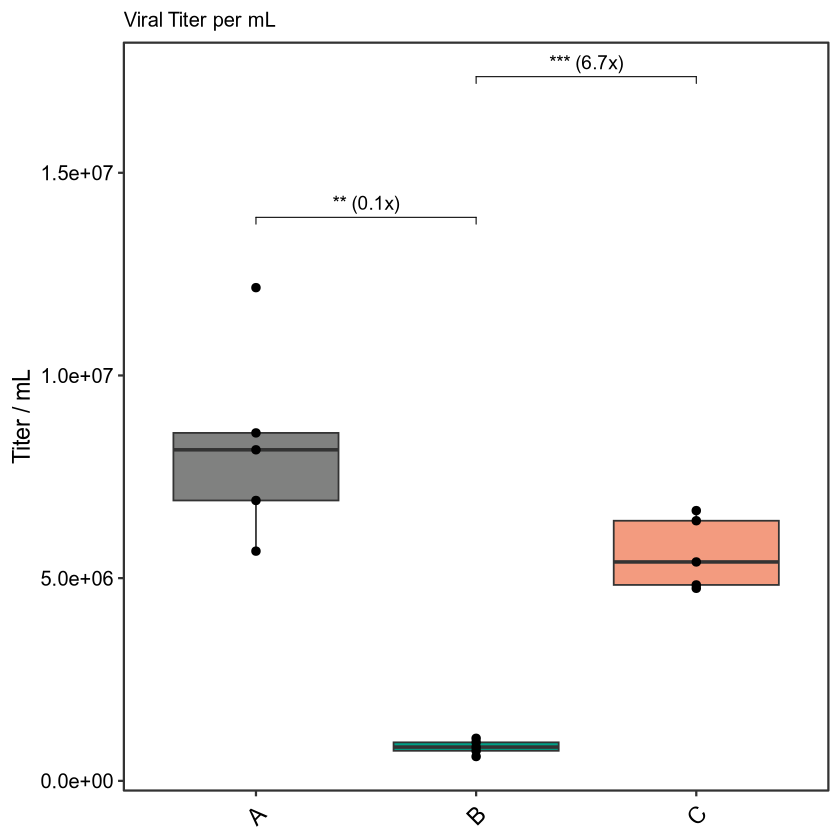

In [ ]:
# Viral titer per mL (raw plaque/focus count, not corrected for spleen fraction) by Group
titerml.plot.stat.df <- plot_padj(
    data = titer,
    comparisons = abc_comparisons,
    y_col = "TiterPerML",
    x_col = "Group",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 1e6
)

write.csv(titerml.plot.stat.df, paste0(output_folder, "/stats-TiterPerML.csv"), row.names = FALSE)

titerml.plot.stat.df <- titerml.plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(titer, aes(x = Group, y = TiterPerML, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        titerml.plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Titer / mL") + ggtitle("Viral Titer per mL")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-TiterPerML.pdf"),
    plot = p,
    width = 2.5,
    height = 3,
    units = "in"
)

In [34]:
titer.plot.stat.df %>% filter(p.adj < 0.05) %>% select(group1, group2, p.adj, y.position)

group1,group2,p.adj,y.position
<chr>,<chr>,<dbl>,<dbl>
A,B,0.0009675,43021175
A,C,0.0250000,56712954
B,C,0.0000423,74762234
